# Predicció del preu dels mòbils

Hem descarregat un dataset de: https://www.kaggle.com/datasets/abdulmalik1518/mobiles-dataset-2025/data

Té característiques i preu de molts telèfons mòbils. Anem a veure si podem predir el preu d'un mòbil en funció de certes característiques bàsiques.


In [24]:
import pandas as pd


df=pd.read_csv("./Mobiles Dataset (2025).csv", encoding='latin-1')
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [19]:

df.info()

<class 'pandas.DataFrame'>
Index: 915 entries, 0 to 929
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company Name      915 non-null    str    
 1   Model Name        915 non-null    str    
 2   Mobile Weight     915 non-null    float64
 3   RAM               913 non-null    float64
 4   Front Camera      865 non-null    float64
 5   Back Camera       511 non-null    float64
 6   Processor         915 non-null    str    
 7   Battery Capacity  915 non-null    int64  
 8   Screen Size       907 non-null    float64
 9   Launched Year     915 non-null    int64  
 10  Price_PKR         914 non-null    float64
 11  Price_INR         915 non-null    int64  
 12  Price_CNY         914 non-null    float64
 13  Price_USD         915 non-null    float64
 14  Price_AED         915 non-null    int64  
dtypes: float64(8), int64(4), str(3)
memory usage: 114.4 KB


In [53]:
df=pd.read_csv("./Mobiles Dataset (2025).csv", encoding='latin-1')
print(df.duplicated().sum()) # Hem detectat duplicats, els eliminem per a que no afecten al model.
df=df.drop_duplicates()

# Remove currency symbols and rename columns
df['Price_PKR'] = df['Launched Price (Pakistan)'].str.replace('PKR ', '').str.replace(',', '')
df['Price_INR'] = df['Launched Price (India)'].str.replace('INR ', '').str.replace(',', '')
df['Price_CNY'] = df['Launched Price (China)'].str.replace('CNY ', '').str.replace('¥', '').str.replace(',', '')
df['Price_USD'] = df['Launched Price (USA)'].str.replace('USD ', '').str.replace(',', '')
df['Price_AED'] = df['Launched Price (Dubai)'].str.replace('AED ', '').str.replace(',', '')

# Drop original price columns
df.drop(['Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 
         'Launched Price (USA)', 'Launched Price (Dubai)'], axis=1, inplace=True)

# Convert price columns to numeric
df['Price_PKR'] = pd.to_numeric(df['Price_PKR'], errors='coerce')
df['Price_INR'] = pd.to_numeric(df['Price_INR'], errors='coerce')
df['Price_CNY'] = pd.to_numeric(df['Price_CNY'], errors='coerce')
df['Price_USD'] = pd.to_numeric(df['Price_USD'], errors='coerce')
df['Price_AED'] = pd.to_numeric(df['Price_AED'], errors='coerce')

# Convert 'Launched Year' to numeric
df['Launched Year'] = pd.to_numeric(df['Launched Year'], errors='coerce')


# Convert RAM and others to numeric
df['RAM'] = pd.to_numeric(df['RAM'].str.replace('GB', ''), errors='coerce')
df['Mobile Weight'] = pd.to_numeric(df['Mobile Weight'].str.replace('g', ''), errors='coerce')
front_extracted = df['Front Camera'].astype(str).str.extract(r'(\d+)\s*MP', expand=False)
df['Front Camera 1'] = pd.to_numeric(front_extracted, errors='coerce')
#df['Back Camera'] = pd.to_numeric(df['Back Camera'].str.replace('MP', ''), errors='coerce')
df['Battery Capacity'] = pd.to_numeric(df['Battery Capacity'].str.replace('mAh', '').str.replace(',', ''), errors='coerce')
df['Screen Size'] = pd.to_numeric(df['Screen Size'].str.replace('inches', ''), errors='coerce')


import pandas as pd
import numpy as np

# 1. Separem la columna pel '+'
cameras_split = df['Back Camera'].astype(str).str.split('+', expand=True)

# 2. Definim les columnes i extraiem només els números amb regex
for i, col_name in enumerate(['back camera 1', 'back camera 2', 'back camera 3']):
    if i in cameras_split.columns:
        # r'(\d+)' busca qualsevol seqüència de números (ex: "50" de "50MP (Main)")
        numbers = cameras_split[i].str.extract(r'(\d+)', expand=False)
        # Convertim a numèric i si no troba res o falla, posem 0
        df[col_name] = pd.to_numeric(numbers, errors='coerce').fillna(0).astype(float)
    else:
        # Si el telèfon no té aquesta càmera (per exemple, només en té 2), posem 0
        df[col_name] = 0.0


df.drop('Back Camera', axis=1, inplace=True)
df.head()

15


,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Processor,Battery Capacity,Screen Size,Launched Year,Price_PKR,Price_INR,Price_CNY,Price_USD,Price_AED,Front Camera 1,back camera 1,back camera 2,back camera 3
0,Apple,iPhone 16 128GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,224999.0,79999,5799.0,799.0,2799,12,48.0,0.0,0.0
1,Apple,iPhone 16 256GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,234999.0,84999,6099.0,849.0,2999,12,48.0,0.0,0.0
2,Apple,iPhone 16 512GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,244999.0,89999,6499.0,899.0,3199,12,48.0,0.0,0.0
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12MP,A17 Bionic,4200,6.7,2024,249999.0,89999,6199.0,899.0,3199,12,48.0,0.0,0.0
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12MP,A17 Bionic,4200,6.7,2024,259999.0,94999,6499.0,949.0,3399,12,48.0,0.0,0.0


In [59]:
print(df.isna().sum()) # Hem detectat valors nuls, els eliminem per a que no afectin al model.

df = df.dropna()


Company Name        0
Model Name          0
Mobile Weight       0
RAM                 0
Front Camera        0
Processor           0
Battery Capacity    0
Screen Size         0
Launched Year       0
Price_PKR           0
Price_INR           0
Price_CNY           0
Price_USD           0
Price_AED           0
Front Camera 1      0
back camera 1       0
back camera 2       0
back camera 3       0
dtype: int64


In [60]:
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Processor,Battery Capacity,Screen Size,Launched Year,Price_PKR,Price_INR,Price_CNY,Price_USD,Price_AED,Front Camera 1,back camera 1,back camera 2,back camera 3
0,Apple,iPhone 16 128GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,224999.0,79999,5799.0,799.0,2799,12,48.0,0.0,0.0
1,Apple,iPhone 16 256GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,234999.0,84999,6099.0,849.0,2999,12,48.0,0.0,0.0
2,Apple,iPhone 16 512GB,174.0,6.0,12MP,A17 Bionic,3600,6.1,2024,244999.0,89999,6499.0,899.0,3199,12,48.0,0.0,0.0
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12MP,A17 Bionic,4200,6.7,2024,249999.0,89999,6199.0,899.0,3199,12,48.0,0.0,0.0
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12MP,A17 Bionic,4200,6.7,2024,259999.0,94999,6499.0,949.0,3399,12,48.0,0.0,0.0


In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 904 entries, 0 to 928
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company Name      904 non-null    str    
 1   Model Name        904 non-null    str    
 2   Mobile Weight     904 non-null    float64
 3   RAM               904 non-null    float64
 4   Front Camera      904 non-null    str    
 5   Processor         904 non-null    str    
 6   Battery Capacity  904 non-null    int64  
 7   Screen Size       904 non-null    float64
 8   Launched Year     904 non-null    int64  
 9   Price_PKR         904 non-null    float64
 10  Price_INR         904 non-null    int64  
 11  Price_CNY         904 non-null    float64
 12  Price_USD         904 non-null    float64
 13  Price_AED         904 non-null    int64  
 14  Front Camera 1    904 non-null    int64  
 15  back camera 1     904 non-null    float64
 16  back camera 2     904 non-null    float64
 17  back camera 3

/tmp/ipykernel_327287/3011617514.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


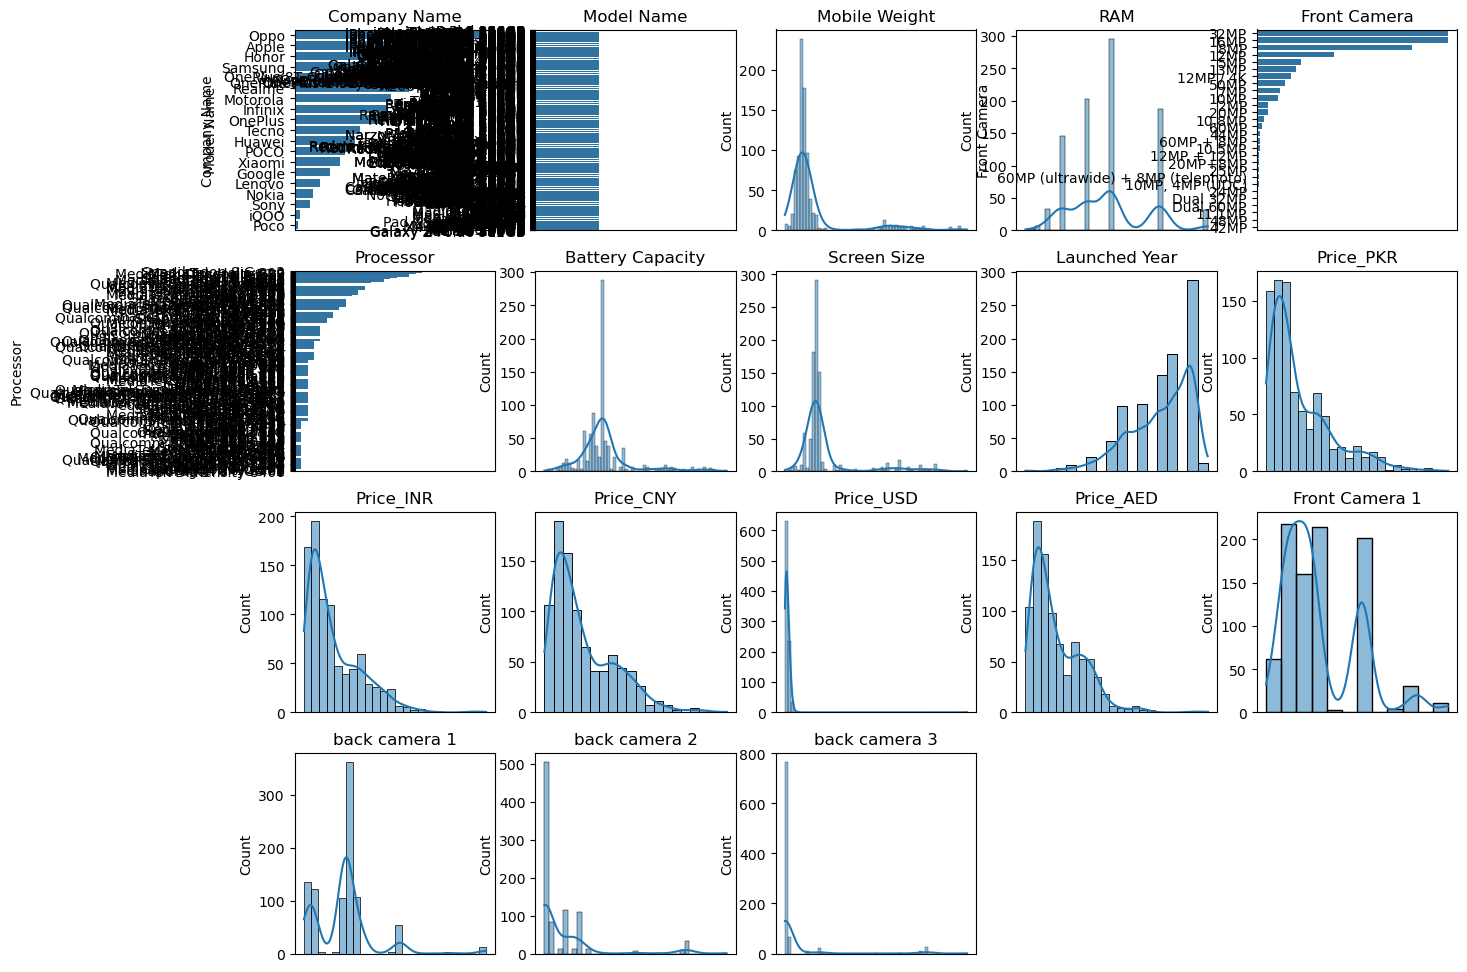

In [62]:
# Mostrem la distribució de cada variable per veure si hi ha valors nuls i com es distribueixen les dades.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))

for i, column in enumerate(df.columns):
    
    if i >= 20:
        break
        
    plt.subplot(4, 5, i + 1)
    
    if df[column].dtype == 'str' or df[column].dtype == 'object':
        sns.countplot(y=df[column], order=df[column].value_counts().index)
    else:
        sns.histplot(df[column], kde=True)
        
    plt.title(column)
    
   
    plt.xlabel('')   # Elimina el text del nom de l'eix X
    plt.xticks([])   # Elimina els números/valors de l'eix X

plt.tight_layout()
plt.show()